In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import sqlite3

In [34]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from '/Users/brittanyloder/Projects/Capstone/notebook/utils.py'>

In [35]:
connection = sqlite3.connect("../database/lfpl_oss_household_demographics.db")
cursor = connection.cursor()

In [36]:
connection.execute("DROP TABLE IF EXISTS louisville_zipcodes;")

connection.execute("""
CREATE TABLE louisville_zipcodes (
    zipcode TEXT PRIMARY KEY
);                   
""")
connection.commit()

In [37]:
connection.execute('DROP TABLE IF EXISTS libraries;')

connection.execute('''
CREATE TABLE libraries (
    library_id INT PRIMARY KEY,
    library_name TEXT, 
    latitude REAL,
    longitude REAL,
    zipcode TEXT,
    FOREIGN KEY (zipcode) REFERENCES louisville_zipcodes(zipcode)
);
''')
connection.commit()

In [38]:
connection.execute('DROP TABLE IF EXISTS library_item_details;')

connection.execute('''
CREATE TABLE library_item_details(
    item_id INT PRIMARY KEY,
    title TEXT,
    item_type TEXT,
    item_collection TEXT,
    item_location TEXT,
    item_price INT
);
''')
connection.commit()

In [39]:
connection.execute("DROP TABLE IF EXISTS library_inventory;")

connection.execute("""
CREATE TABLE library_inventory (
    library_id INT NOT NULL,
    item_id INT NOT NULL,
    PRIMARY KEY (library_id, item_id),
    FOREIGN KEY (library_id) REFERENCES libraries(library_id),
    FOREIGN KEY (item_id) REFERENCES library_item_details(item_id)
);
""")

connection.commit()

In [40]:
connection.execute('DROP TABLE IF EXISTS oss_households;')

connection.execute('''
CREATE TABLE oss_households (
    household_id INT PRIMARY KEY,
    date_added TEXT,
    household_type TEXT,
    household_size INT,
    annual_income BIGINT,
    zipcode TEXT,
    FOREIGN KEY (zipcode) REFERENCES louisville_zipcodes(zipcode)
);
''')

connection.commit()

In [41]:
louisville_zipcodes = utils.csv_to_sql('louisville_zipcodes', '../data/Clean/clean_zips.csv', connection, pd)

In [42]:
libraries = utils.csv_to_sql('libraries', '../data/Clean/clean_lfpl_loc.csv', connection, pd)


In [43]:
library_item_details = utils.csv_to_sql('library_item_details', '../data/Clean/clean_lfpl_inventory.csv', connection, pd)


In [44]:
libraries['library_name'] = libraries['library_name'].str.strip().str.upper()
library_item_details['item_location'] = library_item_details['item_location'].str.strip().str.upper()

In [45]:
library_inventory = library_item_details.merge(
    libraries[['library_id', 'library_name']],
    left_on='item_location',
    right_on='library_name',
    how='inner'
)

In [46]:
library_inventory = library_inventory[['library_id', 'item_id']]

In [47]:
library_inventory = library_inventory.drop_duplicates()

In [48]:
library_inventory.to_sql('library_inventory', connection, if_exists='replace', index=False)

1085827

In [49]:
oss_households = utils.csv_to_sql('oss_households', '../data/Clean/clean_oss.csv', connection, pd)

In [50]:
connection.execute("PRAGMA foreign_keys = ON;")

In [51]:
#OSS Household Count per Library Branch
query1 = pd.read_sql('''
SELECT 
    o.zipcode,
    l.library_name,
    COUNT(o.household_id) AS household_count
FROM libraries l
JOIN oss_households o 
    ON l.zipcode = o.zipcode
GROUP BY o.zipcode, l.library_name
ORDER BY household_count DESC;
''', connection)
query1

,zipcode,library_name,household_count
0,40211,PARKLAND,5189
1,40211,SHAWNEE,5189
2,40216,SHIVELY,4919
3,40203,MAIN,3579
4,40203,WESTERN,3579
5,40212,PORTLAND,3521
6,40215,IROQUOIS,3405
7,40219,SOUTH CENTRAL REGIONAL,2518
8,40218,NEWBURG,2441
9,40272,SOUTHWEST REGIONAL,2174


In [52]:
import geopandas as gpd

lfpl_loc = gpd.read_file("../data/Raw/Louisville_KY_Free_Public_Libraries/Louisville_KY_Free_Public_Libraries.shp")
zipcodes = gpd.read_file("../data/Raw/Jefferson_County_KY_ZIP_Codes/Jefferson_County_KY_ZIP_Codes.shp")

In [53]:
utils.name_fix(query1, 'library_name', lfpl_loc, 'LFPL_NAME')

In [54]:
households_map = lfpl_loc.merge(query1, left_on='LFPL_NAME', right_on='library_name', how='left')

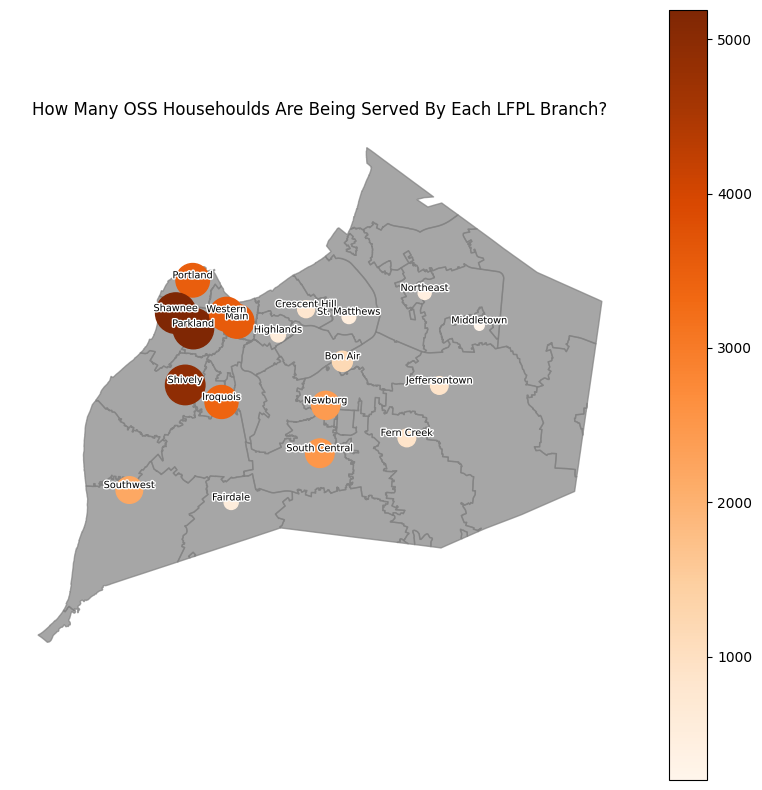

In [55]:
utils.lfpl_map(zipcodes, households_map, 'household_count', 'How Many OSS Househoulds Are Being Served By Each LFPL Branch?', pe, plt, '../plots/OSSHouseholdsPerBranchMap.png')


In [56]:
#Average Annual Income of OSS Households per Library Branch
query2 = pd.read_sql('''
SELECT l.library_name, ROUND(AVG(o.annual_income), 2) as avg_oss_household_annual_income
FROM oss_households o
JOIN libraries l ON o.zipcode = l.zipcode
GROUP BY l.library_name
ORDER BY avg_oss_household_annual_income;
''', connection)
query2

,library_name,avg_oss_household_annual_income
0,MAIN,10167.11
1,WESTERN,10167.11
2,PARKLAND,10912.68
3,SHAWNEE,10912.68
4,PORTLAND,11268.57
5,IROQUOIS,11645.28
6,NEWBURG,12237.14
7,SHIVELY,12408.62
8,CRESCENT HILL,12569.77
9,HIGHLANDS-SHELBY PARK,12857.28


In [57]:
utils.name_fix(query2, 'library_name', lfpl_loc, 'LFPL_NAME')

In [58]:
query2['avg_oss_household_annual_income'] = query2['avg_oss_household_annual_income'].astype('int64')

In [59]:
query2

,library_name,avg_oss_household_annual_income
0,Main,10167
1,Western,10167
2,Parkland,10912
3,Shawnee,10912
4,Portland,11268
5,Iroquois,11645
6,Newburg,12237
7,Shively,12408
8,Crescent Hill,12569
9,Highlands,12857


In [60]:
annual_income_map = lfpl_loc.merge(query2, left_on='LFPL_NAME', right_on='library_name', how='left')

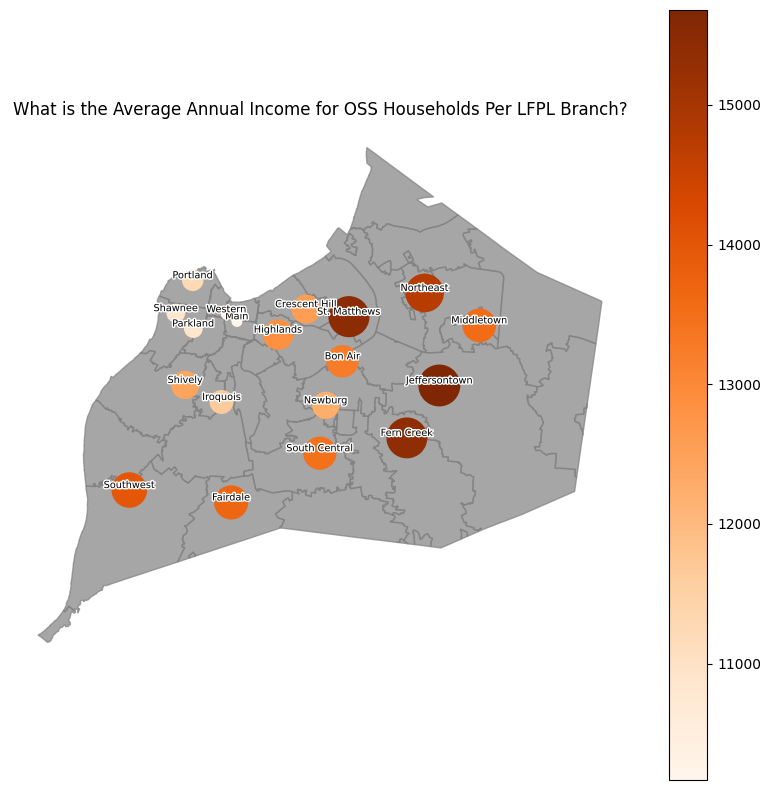

In [61]:
utils.lfpl_map(zipcodes, annual_income_map, 'avg_oss_household_annual_income', 'What is the Average Annual Income for OSS Households Per LFPL Branch?', pe, plt, '../plots/OSSAnnualIncomePerBranchMap.png')


In [62]:
#Library Items Per Branch and Zipcode
query3 = pd.read_sql('''
SELECT lid.item_type, COUNT(lid.item_id) AS item_amt, lid.item_location, l.zipcode
FROM library_item_details lid
JOIN library_inventory li ON lid.item_id = li.item_id
JOIN libraries l ON li.library_id = l.library_id
GROUP BY lid.item_type, lid.item_collection, lid.item_location, l.zipcode
ORDER BY item_amt;
''', connection)
query3

,item_type,item_amt,item_location,zipcode
0,Archival/Mixed Materials,1,Main,40203
1,Archival/Mixed Materials,1,Western,40203
2,Atlas,1,Middletown,40243
3,Atlas,1,Shawnee,40211
4,Atlas,1,Shively,40216
...,...,...,...,...
1127,Book,19913,Bon Air,40220
1128,Book,45050,Main,40203
1129,Eaudiobook,49009,Main,40203
1130,Ebook,151674,Main,40203


In [63]:
#Percentage of Zipcodes with a Library
query4 = pd.read_sql('''
SELECT COUNT(DISTINCT l.zipcode) AS zipcodes_with_library,
    COUNT(DISTINCT lz.zipcode) AS total_louisville_zipcodes,
    COUNT(DISTINCT l.zipcode) * 100 / COUNT(DISTINCT lz.zipcode) AS library_zipcodes_pct
FROM libraries l
RIGHT JOIN louisville_zipcodes lz ON l.zipcode = lz.zipcode;
''', connection)
query4

,zipcodes_with_library,total_louisville_zipcodes,library_zipcodes_pct
0,17,41,41


In [64]:
#Percentage of OSS Zipcodes with a Library
query5 = pd.read_sql('''
SELECT COUNT(DISTINCT l.zipcode) AS zipcodes_with_library,
    COUNT(DISTINCT o.zipcode) AS oss_household_zipcodes,
    COUNT(DISTINCT l.zipcode) * 100 / COUNT(DISTINCT o.zipcode) AS library_oss_zipcode_pct
FROM oss_households o
LEFT JOIN libraries l ON o.zipcode = l.zipcode;
''', connection)
query5

,zipcodes_with_library,oss_household_zipcodes,library_oss_zipcode_pct
0,17,38,44
